# Minimum Cost Spanning Tree
Problem Description:
A spanning tree of a graph can be defined as a graph with minimal set of edges that connect all vertices. A minimum spanning tree of a graph is a spanning tree of the graph with least weight (where the weight is computed by adding the weights of all the edges in the spanning tree). In general, a graph can have multiple minimum spanning trees. The problem is to find a minimum spanning tree of a graph.

This implementation uses a dictionary to represent the weighted graph, where the vertices are keys, and the values are dictionaries containing their adjacent vertices and their weights.

Please note that this implementation assumes that the input graph is connected and weighted.

First, let's create a simple graph to demonstrate Prim's algorithm:

In [10]:
graph = {
    "A": {"B": 10, "C": 15, "D": 20},
    "B": {"A": 10, "C": 12},
    "C": {"A": 15, "B": 12, "D": 18},
    "D": {"A": 20, "C": 18},
}


Now, let's implement Prim's algorithm:

In [11]:
def prim_algorithm(graph):
    start = list(graph.keys())[0]
    visited = {start}
    edges = []
    min_weight = 0

    while len(visited) < len(graph):
        min_edge = float('inf')
        chosen_edge = None

        for vertex in visited:
            for adj_vertex, weight in graph[vertex].items():
                if adj_vertex not in visited and weight < min_edge:
                    min_edge = weight
                    chosen_edge = (vertex, adj_vertex, weight)

        if chosen_edge:
            v1, v2, w = chosen_edge
            edges.append((v1, v2, w))
            visited.add(v2)
            min_weight += w

    return edges, min_weight


graph = {
    "A": {"B": 10, "C": 15, "D": 20},
    "B": {"A": 10, "C": 12},
    "C": {"A": 15, "B": 12, "D": 18},
    "D": {"A": 20, "C": 18},
}

Now, let's run the Prim's algorithm on the example graph:
Keep in mind that this example uses a simple representation of a graph, but for more complex cases, you might want to use a library such as NetworkX to represent and manipulate graphs.

In [12]:
mst, min_weight = prim_algorithm(graph)
print("Minimum Spanning Tree: ", mst)
print("Minimum Weight: ", min_weight)

Minimum Spanning Tree:  [('A', 'B', 10), ('B', 'C', 12), ('C', 'D', 18)]
Minimum Weight:  40


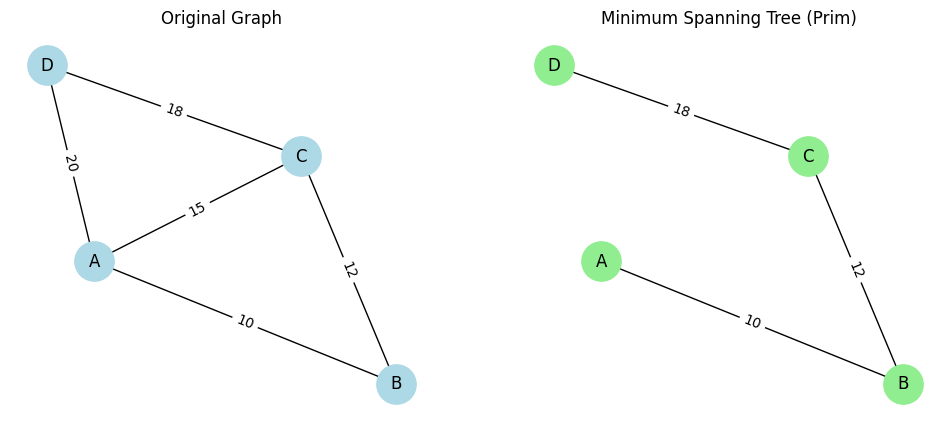

MST Edges: [('A', 'B', {'weight': 10}), ('B', 'C', {'weight': 12}), ('C', 'D', {'weight': 18})]
Total Weight: 40


In [13]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()
for u in graph:
    for v, w in graph[u].items():
        G.add_edge(u, v, weight=w)

# Compute MST using NetworkX's built-in Prim/Kruskal
mst = nx.minimum_spanning_tree(G, algorithm="prim")

# Draw original graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=800, font_size=12)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
plt.title("Original Graph")

# Draw MST
plt.subplot(1,2,2)
nx.draw(mst, pos, with_labels=True, node_color="lightgreen", node_size=800, font_size=12)
nx.draw_networkx_edge_labels(mst, pos, edge_labels=nx.get_edge_attributes(mst, "weight"))
plt.title("Minimum Spanning Tree (Prim)")

plt.show()

# Print MST edges and weight
total_weight = sum(nx.get_edge_attributes(mst, "weight").values())
print("MST Edges:", list(mst.edges(data=True)))
print("Total Weight:", total_weight)

Take Differnt example of input graph as discussed in lecture slide and use above code to verify the output

In [14]:
# your sample input of graph
g2 = {
    "A": {"B": 3, "D": 1},
    "B": {"A": 3, "D": 3, "E": 1},
    "C": {"E": 5, "F": 4},
    "D": {"A": 1, "B": 3, "E": 6},
    "E": {"B": 1, "D": 6, "C": 5, "F": 2},
    "F": {"C": 4, "E": 2},
}

In [15]:
#run prims algorithm for sample input
mst, min_weight = prim_algorithm(g2)
print("Minimum Spanning Tree: ", mst)
print("Minimum Weight: ", min_weight)

Minimum Spanning Tree:  [('A', 'D', 1), ('A', 'B', 3), ('B', 'E', 1), ('E', 'F', 2), ('F', 'C', 4)]
Minimum Weight:  11


Use same apporach for Kruskal's algorithm

In [16]:
# implement Kruskal's algorithm
def kruskal_algorithm(graph):
    parent = {}
    rank = {}

    def find(node):
        if parent[node] != node:
            parent[node] = find(parent[node])
        return parent[node]

    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u != root_v:
            if rank[root_u] < rank[root_v]:
                parent[root_u] = root_v
            elif rank[root_u] > rank[root_v]:
                parent[root_v] = root_u
            else:
                parent[root_v] = root_u
                rank[root_u] += 1

    # Initialize disjoint sets
    for vertex in graph:
        parent[vertex] = vertex
        rank[vertex] = 0

    # Collect edges
    edges = []
    for u in graph:
        for v, w in graph[u].items():
            if (v, u, w) not in edges:  # avoid duplicates
                edges.append((u, v, w))

    # Sort edges by weight
    edges.sort(key=lambda x: x[2])

    mst = []
    min_weight = 0

    for u, v, w in edges:
        if find(u) != find(v):
            union(u, v)
            mst.append((u, v, w))
            min_weight += w

    return mst, min_weight

# Run Kruskal
mst, min_weight= kruskal_algorithm(g2)
print("Kruskal's MST:", mst)
print("Kruskal's Total Weight:", min_weight)


Kruskal's MST: [('A', 'D', 1), ('B', 'E', 1), ('E', 'F', 2), ('A', 'B', 3), ('C', 'F', 4)]
Kruskal's Total Weight: 11
